# Análisis de Riesgo Crediticio — Balance vs Default
**Proyecto:** Simulació Empresarial IT Academy — Bank Marketing  
**Equipo:** Analistas de Finanzas y Riesgo Crediticio  
**Pregunta:** *¿En qué medida los clientes con saldos más bajos presentan un mayor riesgo de impago (default), y cómo debemos ajustar nuestras políticas de crédito para mitigar este riesgo?*

---
**Variables:** `balance` (numérica continua — saldo anual promedio en €) · `default` (binaria — crédito en mora: sí/no)  
**Técnica:** Análisis Bivariado Segmentado — Discretización por percentiles P33/P66 + Test Chi-cuadrado

## 1. Imports y carga de datos

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [53]:
# Cargar el archivo .parquet
df = pd.read_parquet('df_limpiado_260420.parquet')

# Verificar que se cargó correctamente
print("Base de datos cargada:")
print(df.head())

Base de datos cargada:
     age             job  marital  education default  balance housing loan  \
id                                                                           
1   59.0  administration  married  secondary      no     2343     yes   no   
2   56.0  administration  married  secondary      no       45      no   no   
3   41.0      technician  married  secondary      no     1270     yes   no   
4   55.0        services  married  secondary      no     2476     yes   no   
5   54.0  administration  married   tertiary      no      184      no   no   

    contact  day month  duration  campaign  pdays  previous  \
id                                                            
1   unknown    5   may    1042.0         1    NaN         0   
2   unknown    5   may    1467.0         1    NaN         0   
3   unknown    5   may    1389.0         1    NaN         0   
4   unknown    5   may     579.0         1    NaN         0   
5   unknown    5   may     673.0         2    NaN   

In [54]:
variables = pd.DataFrame(columns=['Variable', 'Número de valores unicos', 'Tipo','Valores'])
for i, var in enumerate(df.columns):
    variables.loc[i] = [var, df[var].nunique(), df[var].dtype,df[var].unique().tolist()]

variables

,Variable,Número de valores unicos,Tipo,Valores
0,age,77,float64,"[59.0, 56.0, 41.0, 55.0, 54.0, 42.0, 60.0, 37...."
1,job,12,string[python],"[administration, technician, services, managem..."
2,marital,3,string[python],"[married, single, divorced]"
3,education,4,string[python],"[secondary, tertiary, primary, unknown]"
4,default,2,string[python],"[no, yes]"
5,balance,3703,int64,"[2343, 45, 1270, 2476, 184, 0, 830, 545, 1, 50..."
6,housing,2,string[python],"[yes, no]"
7,loan,2,string[python],"[no, yes]"
8,contact,3,string[python],"[unknown, cellular, telephone]"
9,day,31,int64,"[5, 6, 7, 8, 9, 12, 13, 14, 15, 16, 19, 20, 21..."


In [55]:
df[['balance', 'default']].head()

,balance,default
id,,
1,2343,no
2,45,no
3,1270,no
4,2476,no
5,184,no


## 2. Diagnóstico inicial

Verificamos nulos y la distribución de `balance` para decidir el método de segmentación.

In [56]:
print(f"Nulos en balance: {df['balance'].isnull().sum()} | Nulos en default: {df['default'].isnull().sum()}")
print(f"\nDistribución de default:")
print(df['default'].value_counts())
print(f"Tasa global de impago: {(df['default']=='yes').mean()*100:.2f}%")
df[['balance']].describe().round(1)

Nulos en balance: 0 | Nulos en default: 0

Distribución de default:
default
no     10487
yes      155
Name: count, dtype: Int64
Tasa global de impago: 1.46%


,balance
count,10642.0
mean,1536.6
std,3223.4
min,-6847.0
25%,127.0
50%,558.0
75%,1728.8
max,81204.0


## 3. Distribución de 'balance'

La diferencia entre media (1.537€) y mediana (558€) evidencia la distribución asimétrica.
**Decisión:** usar percentiles P33/P66, no media ± std porque se agruparan pocas personas en los valores extremos(con std , el grupo 'bajo' quedaría con solo 7 clientes).

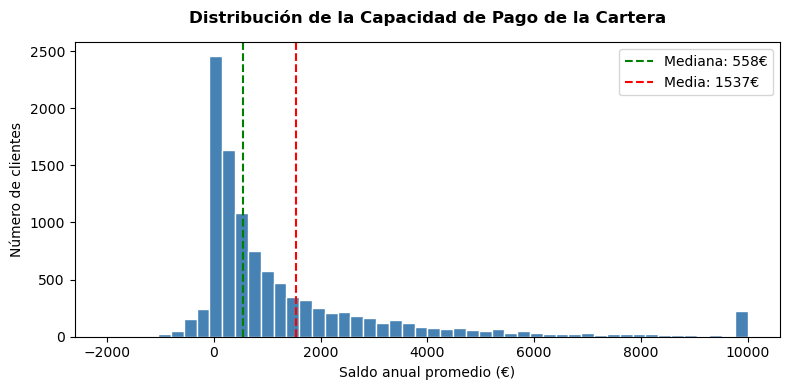

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['balance'].clip(-2000, 10000), bins=50, color='steelblue', edgecolor='white')
ax.axvline(df['balance'].median(), color='green', linestyle='--', label=f"Mediana: {df['balance'].median():.0f}€")
ax.axvline(df['balance'].mean(),   color='red',    linestyle='--', label=f"Media: {df['balance'].mean():.0f}€")
ax.set_title('Distribución de la Capacidad de Pago de la Cartera', fontweight='bold',pad = 14)
ax.set_xlabel('Saldo anual promedio (€)')
ax.set_ylabel('Número de clientes')
ax.legend()
plt.tight_layout()
plt.savefig('00 Distribución de la Capacidad de Pago de la Cartera.png', dpi=150) 
plt.show()

## 4. Segmentación de balance'
Dividimos balance en tres segmentos de tamaño aproximadamente igual usando los percentiles 33 y 66 para que cada grupo tenga suficientes clientes para que las tasas sean estadísticamente fiables.

In [58]:
p33 = df['balance'].quantile(0.33)
p66 = df['balance'].quantile(0.66)
print(f"Límite bajo/medio (P33): {p33:.0f}€ | Límite medio/alto (P66): {p66:.0f}€")

Límite bajo/medio (P33): 237€ | Límite medio/alto (P66): 1139€


In [59]:
# Segmentos
df['balance_cat'] = pd.cut(df['balance'],
                            bins=[-np.inf, p33, p66, np.inf],
                            labels=['bajo', 'medio', 'alto'])

In [60]:
# Distribución resultante
df['balance_cat'].value_counts().sort_index()

balance_cat
bajo     3518
medio    3507
alto     3617
Name: count, dtype: int64

## 5. Tasa de impago por segmento
Se crea una tabla para visualizar cuántos clientes tienen impago en cada segmento.

In [61]:
tabla = (
    df.groupby('balance_cat', observed=True)['default']
    .agg(total='count', con_impago=lambda x: (x == 'yes').sum())
    .assign(
        tasa_impago_pct   = lambda d: (d['con_impago'] / d['total'] * 100).round(2),
        saldo_mediano_eur = df.groupby('balance_cat', observed=True)['balance'].median().round(0)
    )
)
tabla

,total,con_impago,tasa_impago_pct,saldo_mediano_eur
balance_cat,,,,
bajo,3518,132,3.75,25.0
medio,3507,16,0.46,548.0
alto,3617,7,0.19,2600.0


## 6. Riesgo de impago

El riesgo relativo indica cuántas veces más probable es el impago frente al grupo de menor riesgo (alto).  
La diferencia absoluta (resta simple de porcentajes) muestra el impacto directo para el negocio.

In [62]:
# tasa de impago por categoria
tasa_bajo  = tabla.loc['bajo',  'tasa_impago_pct']
tasa_medio = tabla.loc['medio', 'tasa_impago_pct']
tasa_alto  = tabla.loc['alto',  'tasa_impago_pct']

In [63]:
print(f"Tasa de impago — Bajo:  {tasa_bajo}%")
print(f"Tasa de impago — Medio: {tasa_medio}%")
print(f"Tasa de impago — Alto:  {tasa_alto}%")
print()
print(f"Diferencia absoluta (bajo vs alto):  +{round(tasa_bajo - tasa_alto, 2)} puntos porcentuales")
print(f"Diferencia absoluta (bajo vs medio): +{round(tasa_bajo - tasa_medio, 2)} puntos porcentuales")
print()
print(f"Riesgo relativo bajo vs alto:  {round(tasa_bajo / tasa_alto, 1)}x más probable el impago")
print(f"Riesgo relativo medio vs alto: {round(tasa_medio / tasa_alto, 1)}x más probable el impago")

Tasa de impago — Bajo:  3.75%
Tasa de impago — Medio: 0.46%
Tasa de impago — Alto:  0.19%

Diferencia absoluta (bajo vs alto):  +3.56 puntos porcentuales
Diferencia absoluta (bajo vs medio): +3.29 puntos porcentuales

Riesgo relativo bajo vs alto:  19.7x más probable el impago
Riesgo relativo medio vs alto: 2.4x más probable el impago


## 7. Validación estadística — Test Chi-cuadrado
Se verifica si la relación que observamos entre 'balance_cat' y 'default'es estadísticamente significativa o podría deberse al azar.

H₀ (hipótesis nula): No hay relación entre el segmento de saldo y el impago
H₁ (hipótesis alternativa): Sí existe relación entre el segmento de saldo y el impago
Si p < 0.05 → rechazamos H₀ → la relación es real

In [64]:
# Tabla de frecuencias
tabla_contingencia = pd.crosstab(df['balance_cat'], df['default'])
tabla_contingencia

default,no,yes
balance_cat,,
bajo,3386,132
medio,3491,16
alto,3610,7


In [65]:
# Prueba estadística de Independencia Chi-cuadrado de Pearson (Si la diferencia es muy grande, hay relación).
chi2, p, dof, _ = chi2_contingency(tabla_contingencia)

In [66]:
# Visualización de métricas
print(f"Chi-cuadrado (χ²) = {chi2:.2f}")
print(f"p-valor           = {p:.6f}")
print(f"Grados de libertad = {dof}")

Chi-cuadrado (χ²) = 193.82
p-valor           = 0.000000
Grados de libertad = 2


In [67]:
# Interpretación
if p < 0.05:
    print("RESULTADO: Relación estadísticamente significativa (p < 0.05).")
    print("Rechazamos H₀: el saldo del cliente SÍ influye en el riesgo de impago.")
else:
    print("✗ No se puede rechazar H₀.")

RESULTADO: Relación estadísticamente significativa (p < 0.05).
Rechazamos H₀: el saldo del cliente SÍ influye en el riesgo de impago.


## 8. Conclusiones y recomendaciones de política crediticia

### Hallazgos clave

| Segmento | Saldo | Tasa impago | Diferencia vs alto | Riesgo relativo |
|----------|-------|-------------|-------------------|-----------------|
| **Bajo** | ≤ 237 € | 3.75% | **+3.56 p.p.** | **19.7x** |
| **Medio** | 238 – 1.139 € | 0.46% | +0.27 p.p. | 2.4x |
| **Alto** | > 1.139 € | 0.19% | referencia | — |

El 85% de todos los impagos se concentran en el segmento bajo (χ²=193.82, p≈0).

---

### Recomendaciones de política crediticia

**Segmento BAJO (saldo ≤ 237€):**
- Exigir evaluación adicional de capacidad de pago antes de aprobar créditos nuevos
- Aplicar límites máximos reducidos o requerir garantías adicionales

**Sub-segmento saldo NEGATIVO (6.1% de clientes, tasa impago 11.5%):**
- No aprobar nuevos créditos hasta regularizar el saldo
- Ofrecer productos de ahorro programado para estabilizar su posición financiera

**Segmento MEDIO y ALTO:**
- Riesgo controlado (< 0.5%): condiciones estándar o preferentes para fidelización

# VISUALIZACIONES

In [68]:
p33 = df['balance'].quantile(0.33)
p66 = df['balance'].quantile(0.66)
df['balance_cat'] = pd.cut(df['balance'],
                            bins=[-np.inf, p33, p66, np.inf],
                            labels=['bajo', 'medio', 'alto'])

tabla = (
    df.groupby('balance_cat', observed=True)['default']
    .agg(total='count', con_impago=lambda x: (x == 'yes').sum())
    .assign(tasa_impago_pct=lambda d: (d['con_impago'] / d['total'] * 100).round(2))
)

segmentos = ['Bajo\n(≤237€)', 'Medio\n(238-1139€)', 'Alto\n(>1139€)']
tasas     = tabla['tasa_impago_pct'].values
colores   = ['#E63946', '#F4A261', '#2A9D8F']

## 9. Visualizacion 1: Clientes totales e tasa de impago por segmento saldo

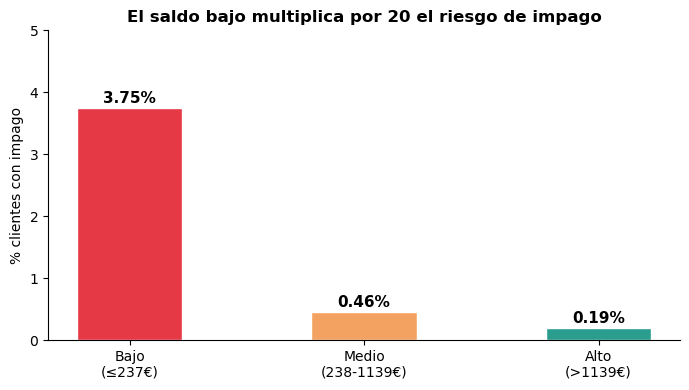

In [69]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(segmentos, tasas, color=colores, width=0.45, edgecolor='white')
for bar, v in zip(bars, tasas):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.08, f'{v}%',
            ha='center', fontweight='bold', fontsize=11)

bars = ax.bar(segmentos, tasas, color=colores, width=0.45, edgecolor='white')

ax.set_title('El saldo bajo multiplica por 20 el riesgo de impago', fontsize=12, fontweight='bold')
ax.set_ylabel('% clientes con impago')
ax.set_ylim(0, 5.0)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz1_tasa_impago.png', dpi=150)
plt.show()

## 10. Visualizacion 2: número absoluto de impagos por segmento
Veremos la concetracion del impago por segmentos

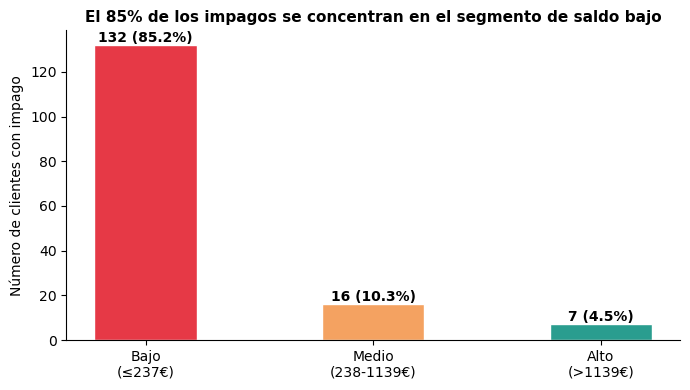

In [70]:
n_impagos = tabla['con_impago'].values
total_impagos = n_impagos.sum()
pct_concentracion = [round(n/total_impagos*100, 1) for n in n_impagos]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(segmentos, n_impagos, color=colores, width=0.45, edgecolor='white')
for bar, n, pct in zip(bars, n_impagos, pct_concentracion):
    ax.text(bar.get_x() + bar.get_width()/2, n + 1.5,
            f'{n} ({pct}%)', ha='center', fontweight='bold', fontsize=10)

ax.set_title('El 85% de los impagos se concentran en el segmento de saldo bajo', fontsize=11, fontweight='bold')
ax.set_ylabel('Número de clientes con impago')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz2_concentracion_impagos.png', dpi=150)
plt.show()

## 11. Visualizacion 3: diferencia en puntos porcentuales respecto al grupo alto

In [71]:
tabla['dif_vs_alto'] = tabla['tasa_impago_pct'] - tabla['tasa_impago_pct']['alto']
tabla

,total,con_impago,tasa_impago_pct,dif_vs_alto
balance_cat,,,,
bajo,3518,132,3.75,3.56
medio,3507,16,0.46,0.27
alto,3617,7,0.19,0.00


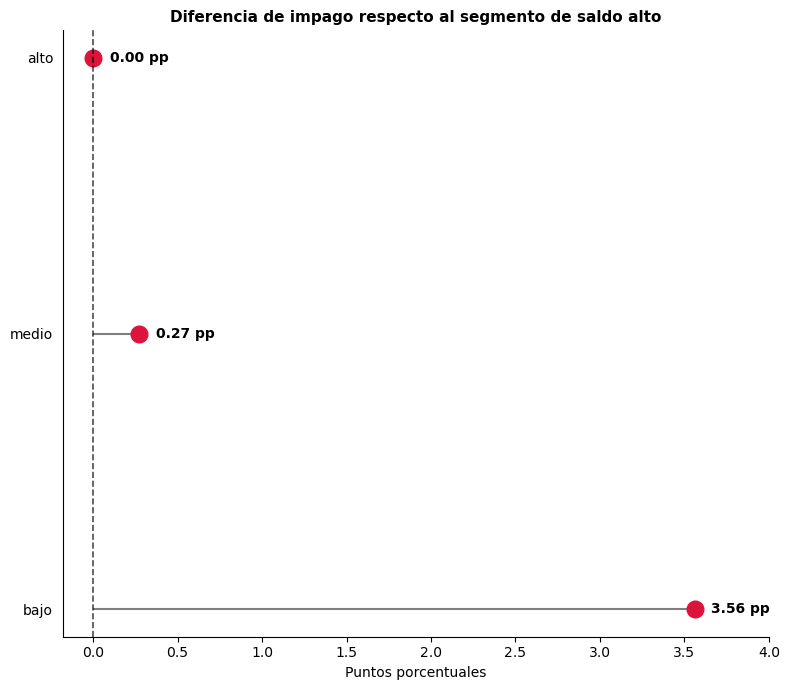

In [72]:
vals = tabla['dif_vs_alto']
cats = tabla.index

fig, ax = plt.subplots(figsize=(8,7))

ax.hlines(y=cats, xmin=0, xmax=vals, color='gray')
ax.plot(vals, cats, "o", markersize=12, color='crimson')

for i, v in enumerate(vals):
    ax.text(
        v + 0.1,
        i,
        f"{v:.2f} pp",
        va='center',
        fontweight='bold'
    )

ax.set_xlim(right=4.0)

# quitar bordes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# opcional
ax.tick_params(left=False)

ax.set_title(
    'Diferencia de impago respecto al segmento de saldo alto',
    fontsize=11,
    fontweight='bold'
)

# Linia vertical de referencia de segmento alto
ax.axvline(
    x=0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7
)

ax.set_xlabel("Puntos porcentuales")

plt.tight_layout()
plt.savefig("viz3_diferencia_pp.png", dpi=150)
plt.show()

# 12 Visualización 4. Tasa de impago: global vs segmentos de mayor riesgo
Por qué: dentro del grupo bajo, los clientes en rojo tienen una tasa de impago del 11.5% — casi 8x la media general. Es el dato más relevante para la política crediticia.

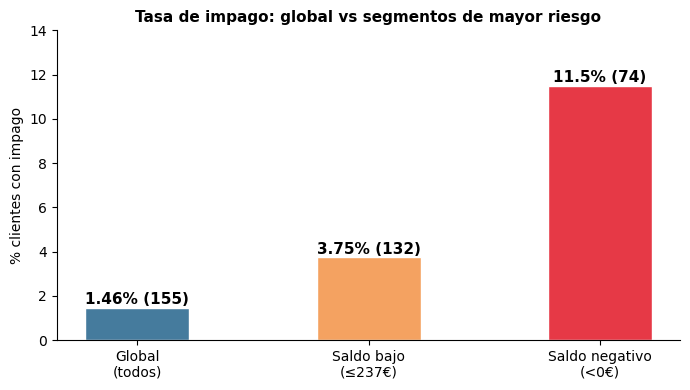

In [73]:
tasa_global = round((df['default']=='yes').mean()*100, 2)

neg  = df[df['balance'] < 0]
tasa_neg = round((neg['default']=='yes').mean()*100, 1)

categorias = ['Global\n(todos)', 'Saldo bajo\n(≤237€)', 'Saldo negativo\n(<0€)']
valores    = [tasa_global, float(tabla.loc['bajo','tasa_impago_pct']), tasa_neg]
cols       = ['#457B9D', '#F4A261', '#E63946']
absolutos = [(df['default']=='yes').sum(), (df[(df['balance_cat']=='bajo') & (df['default']=='yes')]).shape[0], (neg['default']=='yes').sum()]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(categorias, valores, color=cols, width=0.45, edgecolor='white')

for bar, v, n in zip(bars, valores, absolutos):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.15, f'{v}% ({n})',
            ha='center', fontweight='bold', fontsize=11)

ax.set_title('Tasa de impago: global vs segmentos de mayor riesgo', fontsize=11, fontweight='bold')
ax.set_ylabel('% clientes con impago')
ax.set_ylim(0, 14)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz4_saldo_negativo.png', dpi=150)
plt.show()

# Contexto (KPIs Finanzas)

In [74]:
kpi6 = round((df['default'] == 'yes').sum() / len(df) * 100, 2)
print(f"KPI 6 — Tasa global de impago: {kpi6}%")

KPI 6 — Tasa global de impago: 1.46%


In [75]:
kpi7 = round((df['balance'] < 0).sum() / len(df) * 100, 2)
print(f"KPI 7 — Clientes con saldo negativo: {kpi7}%")

KPI 7 — Clientes con saldo negativo: 6.07%


In [76]:
p33 = df['balance'].quantile(0.33)
p66 = df['balance'].quantile(0.66)
df['balance_cat'] = pd.cut(df['balance'], bins=[-np.inf, p33, p66, np.inf], labels=['bajo','medio','alto'])

impagos_bajo  = df[(df['balance_cat'] == 'bajo') & (df['default'] == 'yes')].shape[0]
total_impagos = (df['default'] == 'yes').sum()
kpi8 = round(impagos_bajo / total_impagos * 100, 2)

print(f"KPI 8 — Impagos concentrados en segmento bajo: {kpi8}%")

KPI 8 — Impagos concentrados en segmento bajo: 85.16%
